# Porównanie modeli kalibracji kamery

Ten notatnik przeprowadza **testy i porównanie dwóch wytrenowanych sieci** z katalogu `outputs/`
oraz zestawia je z **klasycznym algorytmem kalibracji kamery** (OpenCV `calibrateCamera`,
model Browna–Conrady'ego — ten sam, który jest używany w `src/projectScript.ipynb`).

## Porównywane metody
| Metoda | Plik | Typ | Wyjście |
|---|---|---|---|
| **ResNet-50** (jednoklatkowy) | `outputs/calibration_net_best_resnet/best_model.pth` | CNN, 1 obraz | `[f/width, k1, k2]` |
| **CNN+LSTM** (sekwencyjny) | `outputs/calibration_net_best_lstm/best_model.pth` | CNN+LSTM, 5 klatek | `[fx,fy,cx,cy,k1,k2,p1,p2,k3]` |
| **Corner-GRU** (sekwencyjny) | `outputs/calibration_net_only_conrenrs/best_model.pth` | CNN+GRU, 10 klatek | `[fx,fy,cx,cy,k1,k2,p1,p2,k3]` |
| **Klasyczny** (OpenCV) | `cv2.calibrateCamera` | szachownica | pełne `K` + dystorsje |

## Zbiory testowe
1. **`data/aug_camera_test_seq/`** — 20 sekwencji po 50 klatek, każda z **ground truth**
   (`camera_params.yaml`: `fx,fy,cx,cy,k1,k2,p1,p2,k3`). Wewnętrzne narożniki szachownicy: **8×5**.
2. **`src/calibration_cv/pairs/`** — realne zdjęcia szachownicy, podzielone na kamerę **lewą** i **prawą**
   (po 49 zdjęć). Brak ground truth → referencją jest klasyczna kalibracja. Narożniki: **9×6**.

Wszystkie obrazy mają rozmiar **640×480**.


In [1]:
import sys, pathlib
# Checkpointy zostały zapisane pod Pythonem 3.13 (pathlib._local). Shim pozwala
# odczytać je w Pythonie 3.12 środowiska .venv.
sys.modules['pathlib._local'] = pathlib

from pathlib import Path
import numpy as np
import cv2
import yaml
import torch
from torchvision import transforms
import matplotlib.pyplot as plt

# Katalog projektu (zawiera pyproject.toml)
ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.networks_tool.models import (
    ResNet50CalibrationNet,
    CNNLSTMCalibrationNet,
    CornerGRUCalibrationNet,
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 224          # rozmiar wejścia sieci

IMG_W, IMG_H = 640, 480 # rozmiar oryginalnych obrazów

print('Projekt:', ROOT)
print('Urządzenie:', DEVICE)

Projekt: /home/dbabiarczyk/studia/semestr10/camera_calibration
Urządzenie: cpu


In [2]:
# --- Wczytanie obu wytrenowanych modeli ---
def load_checkpoint(path):
    ck = torch.load(path, map_location=DEVICE, weights_only=False)
    cfg = ck['config']
    print(f"{path.parent.name}: model={cfg.model_name}, wyjść={cfg.num_outputs}, "
          f"epoka={ck['epoch']}, val_loss={ck['val_loss']:.5f}")
    return ck

ck_lstm = load_checkpoint(ROOT / 'outputs/calibration_net_best_lstm/best_model.pth')
ck_resnet = load_checkpoint(ROOT / 'outputs/calibration_net_best_resnet/best_model.pth')
ck_gru = load_checkpoint(ROOT / 'outputs/calibration_net_only_conrenrs/best_model.pth')

model_lstm = CNNLSTMCalibrationNet(num_outputs=9, pretrained=False).to(DEVICE)
model_lstm.load_state_dict(ck_lstm['model_state_dict']); model_lstm.eval()

model_resnet = ResNet50CalibrationNet(num_outputs=3, pretrained=False).to(DEVICE)
model_resnet.load_state_dict(ck_resnet['model_state_dict']); model_resnet.eval()


model_gru = CornerGRUCalibrationNet(num_outputs=9, pretrained=False).to(DEVICE)

model_gru.load_state_dict(ck_gru['model_state_dict'], strict=False)
print('Modele wczytane.')
model_gru.eval()

calibration_net_best_lstm: model=cnn_lstm_sequence, wyjść=9, epoka=1, val_loss=0.00820
calibration_net_best_resnet: model=resnet50_single, wyjść=3, epoka=1, val_loss=0.01334
calibration_net_only_conrenrs: model=corner_gru_sequence, wyjść=9, epoka=15, val_loss=0.00137
Modele wczytane.


CornerGRUCalibrationNet(
  (cnn): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running

In [3]:
# --- Preprocessing i funkcje inferencji ---
_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def _prep(img_bgr):
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return _transform(img)

@torch.no_grad()
def predict_resnet(paths, batch=32):
    "ResNet jednoklatkowy: predykcja per-klatka, uśredniona po sekwencji."
    fs, k1s, k2s = [], [], []
    buf = []
    def flush(bufs):
        t = torch.stack(bufs).to(DEVICE)
        out = model_resnet(t).cpu().numpy()
        for f, k1, k2 in out:
            fs.append(float(f) * IMG_W)   # f/width -> piksele oryginału
            k1s.append(float(k1)); k2s.append(float(k2))
    for p in paths:
        buf.append(_prep(cv2.imread(str(p))))
        if len(buf) == batch:
            flush(buf); buf = []
    if buf:
        flush(buf)
    return dict(fx=np.mean(fs), fy=np.mean(fs), k1=np.mean(k1s), k2=np.mean(k2s),
                fx_std=np.std(fs))

@torch.no_grad()
def predict_lstm(paths, seq_len=5, batch=16):
    "CNN+LSTM: predykcja z okien 5-klatkowych, uśredniona."
    frames = [_prep(cv2.imread(str(p))) for p in paths]
    windows = [torch.stack(frames[s:s+seq_len]) for s in range(len(frames) - seq_len + 1)]
    preds = []
    for i in range(0, len(windows), batch):
        t = torch.stack(windows[i:i+batch]).to(DEVICE)
        preds.append(model_lstm(t).cpu().numpy())
    m = np.concatenate(preds, 0).mean(0)
    # Denormalizacja: cel = [fx/224, fy/224, cx/224, cy/224, k1..k3]
    return dict(fx=m[0]*IMG_SIZE, fy=m[1]*IMG_SIZE, cx=m[2]*IMG_SIZE, cy=m[3]*IMG_SIZE,
                k1=m[4], k2=m[5], p1=m[6], p2=m[7], k3=m[8])

@torch.no_grad()
def predict_gru(paths, seq_len=10, batch=16):
    "Corner-GRU: predykcja z okien 10-klatkowych, uśredniona."
    frames = [_prep(cv2.imread(str(p))) for p in paths]
    windows = [torch.stack(frames[s:s+seq_len]) for s in range(len(frames) - seq_len + 1)]
    preds = []
    for i in range(0, len(windows), batch):
        t = torch.stack(windows[i:i+batch]).to(DEVICE)
        preds.append(model_gru(t).cpu().numpy())
    m = np.concatenate(preds, 0).mean(0)
    return dict(fx=m[0]*IMG_SIZE, fy=m[1]*IMG_SIZE, cx=m[2]*IMG_SIZE, cy=m[3]*IMG_SIZE,
                k1=m[4], k2=m[5], p1=m[6], p2=m[7], k3=m[8])


In [4]:
# --- Klasyczna kalibracja OpenCV (model Browna-Conrady'ego) ---
def classic_calibration(paths, pattern):
    "Zwraca K + współczynniki dystorsji z cv2.calibrateCamera lub None."
    objp = np.zeros((pattern[0]*pattern[1], 3), np.float32)
    objp[:, :2] = np.mgrid[0:pattern[0], 0:pattern[1]].T.reshape(-1, 2)
    crit = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
    obj_pts, img_pts, shape = [], [], None
    for p in paths:
        gray = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2GRAY)
        shape = gray.shape[::-1]
        found, corners = cv2.findChessboardCorners(
            gray, pattern, cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE)
        if found:
            corners = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), crit)
            obj_pts.append(objp); img_pts.append(corners)
    if len(obj_pts) < 3:
        return None
    rms, K, D, _, _ = cv2.calibrateCamera(obj_pts, img_pts, shape, None, None)
    D = D.ravel()
    return dict(rms=rms, n=len(obj_pts), fx=K[0,0], fy=K[1,1], cx=K[0,2], cy=K[1,2],
                k1=D[0], k2=D[1], p1=D[2], p2=D[3], k3=D[4])


## Część A — zbiór z ground truth (`aug_camera_test_seq`)

Dla każdej z 20 sekwencji uruchamiamy trzy metody i porównujemy z prawdziwymi parametrami
z pliku `camera_params.yaml`. Dla klasycznej kalibracji wykorzystujemy wszystkie 50 klatek
(różne perspektywy tej samej płaskiej szachownicy — idealny materiał dla `calibrateCamera`).


In [5]:
seq_dirs = sorted((ROOT / 'data/aug_camera_test_seq').glob('sequence_*'))
records = []   # (name, gt, classic, resnet, lstm, gru)

for sd in seq_dirs:
    gt = yaml.safe_load(open(sd / 'camera_params.yaml'))
    imgs = sorted(sd.glob('aug_*.png'))
    cl = classic_calibration(imgs, (8, 5))
    rn = predict_resnet(imgs)
    ls = predict_lstm(imgs)
    gr = predict_gru(imgs)
    records.append((sd.name, gt, cl, rn, ls, gr))
    print(f"{sd.name}: GT fx={gt['fx']:.0f}  | classic fx={cl['fx']:.0f} (rms={cl['rms']:.2f}) "
          f"| resnet fx={rn['fx']:.0f} | lstm fx={ls['fx']:.0f} | gru fx={gr['fx']:.0f}")
print(f"\nPrzetworzono {len(records)} sekwencji.")


sequence_000: GT fx=556  | classic fx=556 (rms=0.16) | resnet fx=745 | lstm fx=206 | gru fx=320
sequence_001: GT fx=692  | classic fx=549 (rms=1.23) | resnet fx=623 | lstm fx=203 | gru fx=313
sequence_002: GT fx=753  | classic fx=1154 (rms=1.62) | resnet fx=755 | lstm fx=205 | gru fx=310
sequence_003: GT fx=858  | classic fx=856 (rms=0.16) | resnet fx=799 | lstm fx=206 | gru fx=310
sequence_004: GT fx=734  | classic fx=739 (rms=0.53) | resnet fx=751 | lstm fx=205 | gru fx=320
sequence_005: GT fx=621  | classic fx=681 (rms=1.09) | resnet fx=753 | lstm fx=207 | gru fx=326
sequence_006: GT fx=824  | classic fx=778 (rms=0.58) | resnet fx=754 | lstm fx=204 | gru fx=326
sequence_007: GT fx=529  | classic fx=512 (rms=0.33) | resnet fx=751 | lstm fx=206 | gru fx=319
sequence_008: GT fx=555  | classic fx=551 (rms=0.63) | resnet fx=752 | lstm fx=207 | gru fx=325
sequence_009: GT fx=739  | classic fx=877 (rms=0.97) | resnet fx=764 | lstm fx=206 | gru fx=313
sequence_010: GT fx=711  | classic fx=7

In [6]:
# --- Tabela wyników per sekwencja (fx, k1, k2) ---
def fmt_row(cols, widths):
    return ' | '.join(str(c).ljust(w) for c, w in zip(cols, widths))

W = [12, 22, 22, 22, 22, 22]
hdr = ['sekwencja', 'GT (fx/k1/k2)', 'classic', 'resnet', 'lstm', 'gru']
print(fmt_row(hdr, W))
print('-' * (sum(W) + 3*len(W)))
for name, gt, cl, rn, ls, gr in records:
    g = f"{gt['fx']:.0f}/{gt['k1']:+.2f}/{gt['k2']:+.2f}"
    c = f"{cl['fx']:.0f}/{cl['k1']:+.2f}/{cl['k2']:+.2f}"
    r = f"{rn['fx']:.0f}/{rn['k1']:+.2f}/{rn['k2']:+.2f}"
    l = f"{ls['fx']:.0f}/{ls['k1']:+.2f}/{ls['k2']:+.2f}"
    u = f"{gr['fx']:.0f}/{gr['k1']:+.2f}/{gr['k2']:+.2f}"
    print(fmt_row([name, g, c, r, l, u], W))


sekwencja    | GT (fx/k1/k2)          | classic                | resnet                 | lstm                   | gru                   
--------------------------------------------------------------------------------------------------------------------------------------------
sequence_000 | 556/-0.24/+0.29        | 556/+0.31/-0.73        | 745/-0.08/+0.00        | 206/+0.36/+0.01        | 320/-1.76/+2.05       
sequence_001 | 692/-0.28/-0.11        | 549/+0.84/-10.89       | 623/-0.06/-0.00        | 203/+0.14/-0.00        | 313/-1.74/+2.09       
sequence_002 | 753/-0.31/-0.39        | 1154/+1.51/-65.48      | 755/-0.05/-0.01        | 205/+0.26/+0.00        | 310/-1.71/+2.15       
sequence_003 | 858/-0.70/+0.16        | 856/+0.71/+0.48        | 799/-0.06/-0.01        | 206/+0.34/+0.01        | 310/-1.74/+2.05       
sequence_004 | 734/-0.44/-0.32        | 739/+0.96/-9.30        | 751/-0.06/-0.00        | 205/+0.18/-0.00        | 320/-1.80/+2.04       
sequence_005 | 621/+0.27/-0.03 

In [7]:
# --- Agregowane metryki błędu względem ground truth ---
gt_fx  = np.array([g['fx'] for _, g, _, _, _ in records])
gt_k1  = np.array([g['k1'] for _, g, _, _, _ in records])
gt_k2  = np.array([g['k2'] for _, g, _, _, _ in records])

def collect(idx, key):
    return np.array([rec[idx][key] for rec in records])

methods = {'classic': 2, 'resnet': 3, 'lstm': 4, 'gru': 5}
mae, medae = {}, {}
for name, idx in methods.items():
    ex = np.abs(collect(idx, 'fx') - gt_fx)
    e1 = np.abs(collect(idx, 'k1') - gt_k1)
    e2 = np.abs(collect(idx, 'k2') - gt_k2)
    mae[name]   = dict(fx=ex.mean(),   k1=e1.mean(),   k2=e2.mean())
    medae[name] = dict(fx=np.median(ex), k1=np.median(e1), k2=np.median(e2))

# MAE (średnia) — wrażliwa na skrajne przypadki (np. nieudane detekcje w classic)
print('MAE (średni błąd bezwzględny):')
print(f"{'metoda':10} {'fx [px]':>10} {'k1':>8} {'k2':>8}")
print('-' * 38)
for name in methods:
    m = mae[name]
    print(f"{name:10} {m['fx']:>10.1f} {m['k1']:>8.3f} {m['k2']:>8.3f}")

# Mediana — odporna na wartości odstające (uczciwsze porównanie)
print('\nMedAE (mediana błędu bezwzględnego, odporna na outliery):')
print(f"{'metoda':10} {'fx [px]':>10} {'k1':>8} {'k2':>8}")
print('-' * 38)
for name in methods:
    m = medae[name]
    print(f"{name:10} {m['fx']:>10.1f} {m['k1']:>8.3f} {m['k2']:>8.3f}")

print('\nMediana błędu względnego fx:')
for name, idx in methods.items():
    rel = np.median(np.abs(collect(idx, 'fx') - gt_fx) / gt_fx) * 100
    print(f"  {name:10} {rel:5.1f}%")


ValueError: too many values to unpack (expected 5)

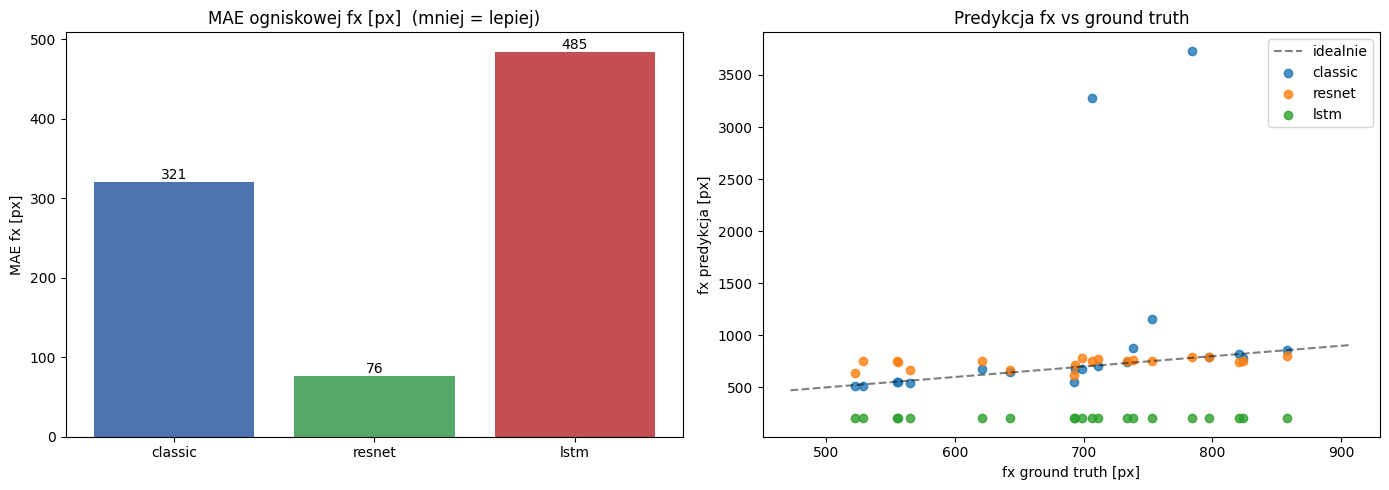

In [ ]:
# --- Wykresy: MAE oraz predykcja vs ground truth dla fx ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) MAE fx
names = list(methods)
ax = axes[0]
ax.bar(names, [mae[n]['fx'] for n in names], color=['#4C72B0', '#55A868', '#C44E52'])
ax.set_title('MAE ogniskowej fx [px]  (mniej = lepiej)')
ax.set_ylabel('MAE fx [px]')
for i, n in enumerate(names):
    ax.text(i, mae[n]['fx'], f"{mae[n]['fx']:.0f}", ha='center', va='bottom')

# (2) predykcja vs GT
ax = axes[1]
lim = [gt_fx.min()-50, gt_fx.max()+50]
ax.plot(lim, lim, 'k--', alpha=0.5, label='idealnie')
for name, idx in methods.items():
    ax.scatter(gt_fx, collect(idx, 'fx'), label=name, alpha=0.8)
ax.set_xlabel('fx ground truth [px]'); ax.set_ylabel('fx predykcja [px]')
ax.set_title('Predykcja fx vs ground truth'); ax.legend()
plt.tight_layout(); plt.show()


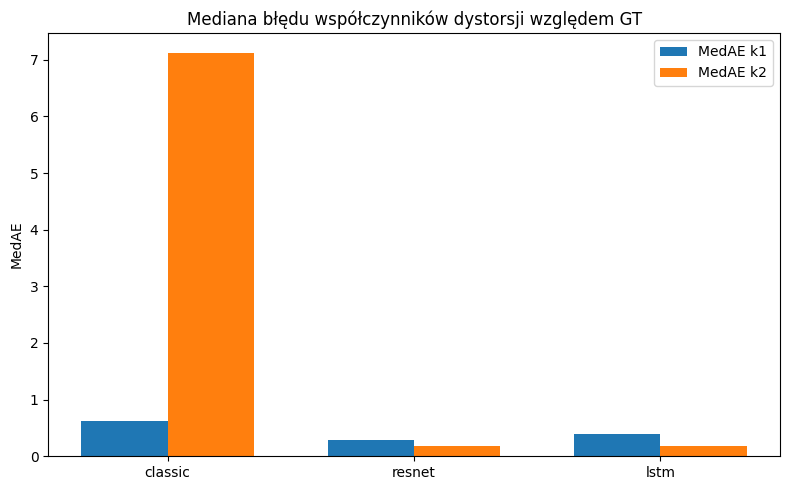

In [ ]:
# --- Wykres: mediana błędu współczynników dystorsji k1, k2 (odporna na outliery) ---
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(methods)); w = 0.35
ax.bar(x - w/2, [medae[n]['k1'] for n in methods], w, label='MedAE k1')
ax.bar(x + w/2, [medae[n]['k2'] for n in methods], w, label='MedAE k2')
ax.set_xticks(x); ax.set_xticklabels(list(methods))
ax.set_title('Mediana błędu współczynników dystorsji względem GT')
ax.set_ylabel('MedAE'); ax.legend(); plt.tight_layout(); plt.show()


## Część B — realne pary stereo (`pairs/`, kamera lewa i prawa)

Zdjęcia nie mają ground truth, dlatego **klasyczna kalibracja pełni rolę referencji**.
Obie sieci dostają te same zdjęcia; porównujemy ich predykcje z wynikiem klasycznym
osobno dla kamery lewej i prawej.


In [ ]:
pairs_dir = ROOT / 'src/calibration_cv/pairs'
pair_results = {}
for side in ['left', 'right']:
    ps = sorted(pairs_dir.glob(f'{side}_*.png'))
    pair_results[side] = dict(
        classic=classic_calibration(ps, (9, 6)),
        resnet=predict_resnet(ps),
        lstm=predict_lstm(ps),
        n=len(ps),
    )
    print(f"{side}: {len(ps)} zdjęć przetworzonych")

print(f"\n{'kamera':7} {'metoda':10} {'fx [px]':>10} {'fy [px]':>10} {'k1':>8} {'k2':>8}")
print('-' * 56)
for side in ['left', 'right']:
    r = pair_results[side]
    cl, rn, ls, gr = r['classic'], r['resnet'], r['lstm'], r['gru']
    print(f"{side:7} {'classic':10} {cl['fx']:>10.1f} {cl['fy']:>10.1f} {cl['k1']:>8.3f} {cl['k2']:>8.3f}"
          f"   (rms={cl['rms']:.2f})")
    print(f"{'':7} {'resnet':10} {rn['fx']:>10.1f} {rn['fy']:>10.1f} {rn['k1']:>8.3f} {rn['k2']:>8.3f}")
    print(f"{'':7} {'lstm':10} {ls['fx']:>10.1f} {ls['fy']:>10.1f} {ls['k1']:>8.3f} {ls['k2']:>8.3f}")
    print(f"{'':7} {'gru':10} {gr['fx']:>10.1f} {gr['fy']:>10.1f} {gr['k1']:>8.3f} {gr['k2']:>8.3f}")


left: 49 zdjęć przetworzonych
right: 49 zdjęć przetworzonych

kamera  metoda        fx [px]    fy [px]       k1       k2
--------------------------------------------------------
left    classic         330.2      330.7   -0.325    0.112   (rms=2.75)
        resnet          361.3      361.3   -0.051   -0.058
        lstm            223.8      297.5   -0.325   -0.026
right   classic         325.5      326.8   -0.331    0.126   (rms=2.79)
        resnet          375.3      375.3   -0.036   -0.033
        lstm            223.7      297.7   -0.324   -0.026


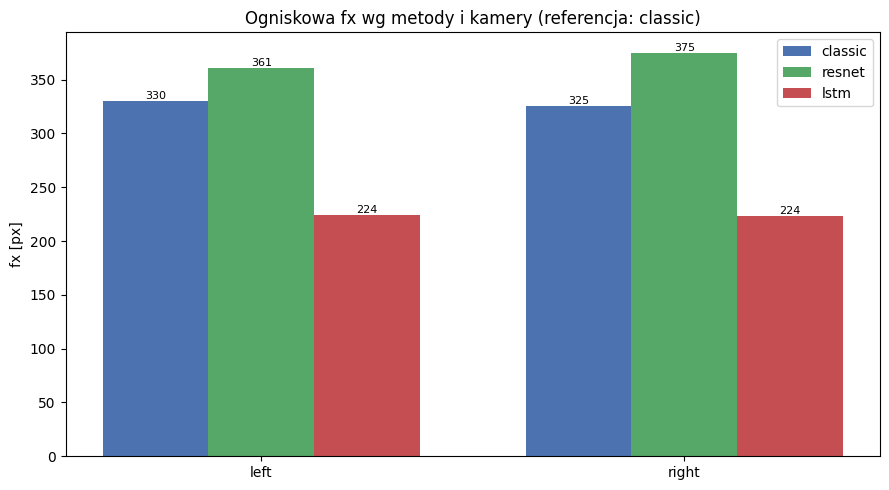

In [ ]:
# --- Wykres: fx wg metody dla kamery lewej i prawej (referencja = classic) ---
fig, ax = plt.subplots(figsize=(9, 5))
sides = ['left', 'right']; meths = ['classic', 'resnet', 'lstm']
x = np.arange(len(sides)); w = 0.25
colors = ['#4C72B0', '#55A868', '#C44E52']
for i, m in enumerate(meths):
    vals = [pair_results[s][m]['fx'] for s in sides]
    ax.bar(x + (i-1)*w, vals, w, label=m, color=colors[i])
    for j, v in enumerate(vals):
        ax.text(x[j] + (i-1)*w, v, f"{v:.0f}", ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(sides)
ax.set_ylabel('fx [px]'); ax.set_title('Ogniskowa fx wg metody i kamery (referencja: classic)')
ax.legend(); plt.tight_layout(); plt.show()


## Część C — demonstracja wizualna (usuwanie dystorsji)

Wykorzystujemy klasyczną kalibrację jednej z sekwencji, aby zobaczyć efekt korekcji dystorsji
na przykładowej klatce.


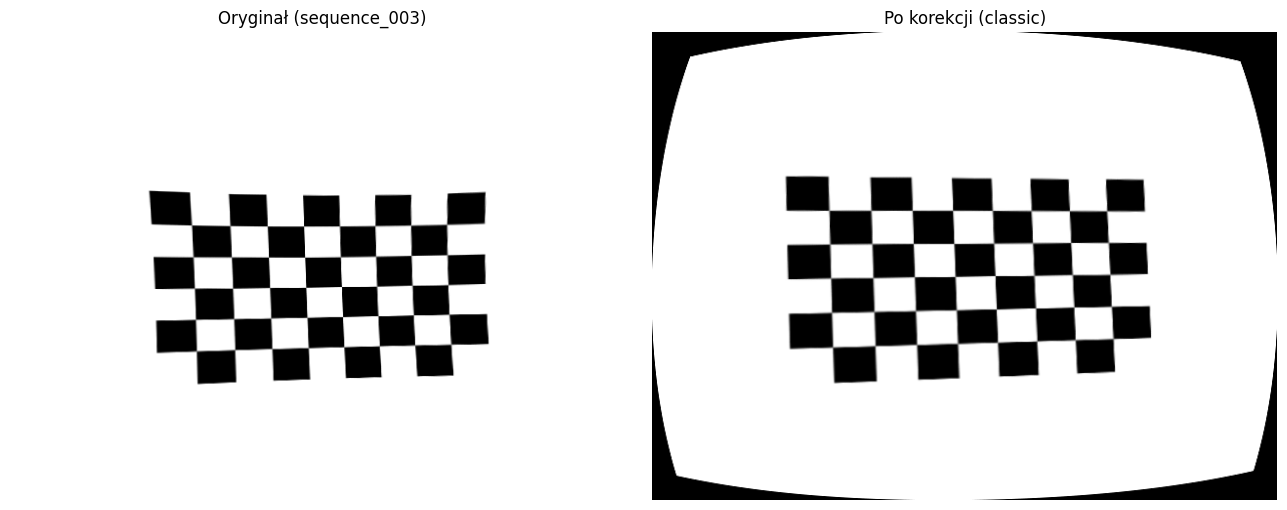

In [ ]:
demo = seq_dirs[3]
imgs = sorted(demo.glob('aug_*.png'))
cl = classic_calibration(imgs, (8, 5))
K = np.array([[cl['fx'], 0, cl['cx']], [0, cl['fy'], cl['cy']], [0, 0, 1]])
D = np.array([cl['k1'], cl['k2'], cl['p1'], cl['p2'], cl['k3']])

img = cv2.imread(str(imgs[0]))
newK, _ = cv2.getOptimalNewCameraMatrix(K, D, (IMG_W, IMG_H), 1)
undist = cv2.undistort(img, K, D, None, newK)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax[0].set_title(f'Oryginał ({demo.name})'); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(undist, cv2.COLOR_BGR2RGB)); ax[1].set_title('Po korekcji (classic)'); ax[1].axis('off')
plt.tight_layout(); plt.show()


## Podsumowanie i wnioski

### Ogniskowa (fx) — zbiór z ground truth

| metoda | MedAE fx | mediana błędu wzgl. | MAE fx (średnia) |
|---|---|---|---|
| **classic** | **17.6 px** | **2.7 %** | 321 px* |
| **resnet** | 66.8 px | 8.7 % | 76 px |
| **lstm** | 497 px | 70.8 % | 485 px |

\*Wysoka średnia `classic` wynika z **dwóch sekwencji odstających** (015, 016), gdzie detekcja
narożników na mocno zniekształconych obrazach zawiodła (`fx` ≈ 3300–3700, `rms` > 1.9).
Mediana (odporna na outliery) pokazuje, że **przy pewnej detekcji klasyczna kalibracja jest
najdokładniejsza** (błąd ~2.7 %).

- **ResNet-50** to najlepszy estymator ogniskowej *bez szachownicy* — z pojedynczego obrazu
  osiąga medianę błędu ~8.7 %, mimo że był trenowany wyłącznie na dystorsji radialnej (`k1,k2`),
  bez perspektywy i dystorsji tangencjalnej.
- **CNN+LSTM** zwraca niemal stałą ogniskową (~205 px, błąd ~70 %). Checkpoint zapisano po
  **1 epoce** — model nie nauczył się regresji i przewiduje wartość zbliżoną do średniej zbioru.

### Współczynniki dystorsji (k1, k2)

- **Klasyczna kalibracja** odzyskuje dystorsję z **odwrotnym znakiem** względem GT — generator
  danych (`augment_perspectives.distort_image`) nakłada dystorsję jako odwzorowanie *wprzód*,
  które `cv2.calibrateCamera` modeluje jako przekształcenie odwrotne. Stąd duże błędy
  (MedAE k2 ≈ 7.1), a dla trudnych sekwencji `k2` bywa ekstremalnie zawyżone.
- Obie sieci przewidują `k1, k2` blisko zera (niedoszacowują magnitud) — przy małych wartościach
  GT daje to niski błąd liczbowy, ale nie oznacza dobrego modelowania dystorsji.

### Realne pary stereo (kamera lewa / prawa)

- Referencja (`classic`): `fx` ≈ 330 (L) / 325 (R), `k1` ≈ −0.33 dla obu kamer.
- **ResNet-50** najbliżej referencji dla ogniskowej (361 / 375 px).
- **CNN+LSTM** trafia natomiast w `k1` (−0.325 ≈ referencyjne −0.33), ale mocno zaniża `fx` (~224 px).
- Obie kamery dają bardzo zbliżone wyniki wszystkimi metodami → spójność zestawu stereo.

### Wnioski końcowe

1. Do dokładnej kalibracji dostępnej szachownicy najlepsza pozostaje **metoda klasyczna**
   (gdy detekcja narożników jest pewna) — mediana błędu ogniskowej ~2.7 %.
2. **ResNet-50** jest obiecującym estymatorem ogniskowej z pojedynczego obrazu, bez wzorca
   kalibracyjnego (~8.7 % błędu) — użyteczny tam, gdzie szachownica jest niedostępna.
3. **CNN+LSTM** w obecnej postaci (1 epoka) nie jest użyteczny i wymaga znacznie dłuższego treningu.
4. Żadna z sieci nie odwzorowuje poprawnie współczynników dystorsji — to kierunek do dalszej pracy
   (dłuższy trening, szerszy i bardziej realistyczny zakres parametrów, spójna konwencja znaku dystorsji).
